In [1]:
import sys
from pathlib import Path

import numpy as np
from bayesian_order_based_learning.metrics import *

sys.path.append(str(Path.cwd().parent / "bayesian_order_based_learning"))

In [2]:
from simulation.simulation import Simulation

/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-24 14:55:34,822	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [10]:
p = 40
sigma = np.arange(p)
np.random.shuffle(sigma)

sim = Simulation(sigma, 1000, 1, verbose=True)

In [11]:
predicted_orderings, predicted_dags, log_posteriors = sim.simulate()

MCMC Sampling wth R2R: 100%|██████████| 32000/32000 [2:55:08<00:00,  3.05it/s]     


In [12]:
true_dags = sim.get_true_dags()
true_posterior = sim.get_true_posterior()

In [10]:
tau_star_K2 = rank_correlation(predicted_orderings, sigma)

In [ ]:
sim2 = Simulation(sigma, 200, 10, verbose=True)
predicted_orderings2, predicted_dags2, log_posteriors2 = sim.simulate()

tau_star_K10 = rank_correlation(predicted_orderings2, sigma)

In [27]:
common_edges = [[], []]
diff_edges = [[], []]
for k, dag in enumerate(true_dags):
    temp = predicted_dags[-1][k]
    for e in temp.edges():
        if e in dag.edges():
            common_edges[k].append(e)
        else:
            diff_edges[k].append(e)

edges_not_counted = [[], []]
for k, dag in enumerate(true_dags):
    temp = predicted_dags[-1][k]
    for e in dag.edges():
        if e not in temp.edges():
            edges_not_counted[0].append(e)


In [15]:
predicted_orderings[-1]

array([23, 19, 13,  3,  6, 21,  5, 33,  9, 10, 39, 17,  2, 25, 24, 29, 27,
       20, 26, 22, 35, 34, 16, 18, 36, 15, 30, 11,  7, 32, 28, 14, 31, 38,
        8, 37,  1,  4, 12,  0])

In [16]:
sigma

array([34,  3,  6, 33, 21, 36,  9, 32, 35,  5, 15, 11, 18, 17, 39, 24, 10,
       13,  2, 30,  1, 29, 22, 25, 23, 19, 26,  7, 27, 16, 14, 28, 37,  8,
       20, 31,  0, 12, 38,  4])

In [28]:
print(f"Common edges: {common_edges}")
print(f"Different edges: {diff_edges}")
print(f"Unaccounted edges: {edges_not_counted}")

Common edges: [[(2, 29), (3, 37), (6, 0), (6, 10), (6, 17), (6, 28), (10, 8), (10, 28), (11, 1), (11, 8), (13, 26), (15, 28), (15, 37), (16, 8), (16, 28), (17, 4), (17, 31), (21, 16), (21, 31), (24, 7), (24, 16), (27, 8), (27, 31), (28, 38), (29, 16), (30, 1), (30, 38), (37, 12), (39, 0)], []]
Different edges: [[(27, 15), (30, 32), (35, 36)], []]
Unaccounted edges: [[(15, 27), (32, 30), (36, 35)], []]


In [18]:
len(true_dags[0].edges()), len(predicted_dags[-1][0].edges())

(32, 32)

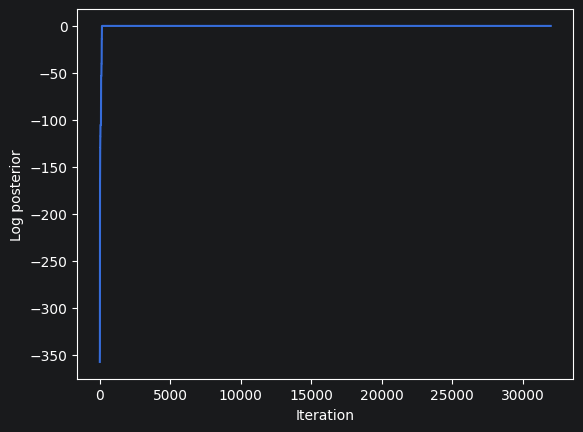

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=range(32001), y=(np.array(log_posteriors) - true_posterior))
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

In [22]:
true_posterior

-137292.0407115757

In [24]:
log_posteriors[-1]

-137292.0407115757